In [1]:
import numpy as np 
from netCDF4 import Dataset
import os
import tensorflow as tf
import argparse
import pandas as pd
from tensorflow import keras

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import time
import matplotlib
import matplotlib.ticker as mticker
import warnings

%matplotlib inline

2025-04-22 19:00:57.655688: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX512_VNNI
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-04-22 19:00:58.015592: I tensorflow/core/util/port.cc:104] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
# HOME = "/scistor/ivm/the410/"

HOME = "/home/thappe/" #snellius

In [3]:
os.chdir(f"{HOME}HeaT")
#sys.path.append(os.path.expanduser('/home/thappe/HeaT'))

from HeaT.TFrecord_utils_ERA_v2 import *

In [4]:
pwd

'/gpfs/home4/thappe/HeaT'

In [5]:
### GLOBAL VARIABLES IVM

os.chdir(HOME)

#IVM 
# data_path = "/scistor/ivm/the410/PAPER3"

#SNELLIUS
data_path = "/home/thappe/data/VAE_MODEL"

In [6]:
ls /home/thappe/data/VAE_MODEL

ERA5_t2m_dynamic_encoded_heatwaves_L128.csv
ERA5_t2m_dynamic_heatwaves_dates.csv
ERA5_t2m_encoded_heatwaves_L128.csv
ERA5_t2m_heatwaves_dates.csv
ERA5_t2m_minus_thermo_encoded_heatwaves_L128.csv
ERA5_t2m_minus_thermo_heatwaves_dates.csv
GMM.pkl
Kmeanseucl.pkl
LENTIS_classes_VAE_L128_1000epochs.csv
LENTIS_Heatwave_means_VAE_L128_1000epochs.csv
VAE3D_3D_noRSDS_5d_TRANSFER_L128_B0.01_F4_AUGMENTED_final.h5


## LOADING DATA  ERA5

In [7]:
t2m_name = "t2m_minus_thermo" 

assert t2m_name in ["t2m", "t2m_dynamic", "t2m_minus_thermo"], "data not available for this var"

VAE_model = (128, f"{data_path}/VAE3D_3D_noRSDS_5d_TRANSFER_L128_B0.01_F4_AUGMENTED_final.h5")

In [10]:
##load heatwave means from csv and datetime information 

heatwave_means_era5 = pd.read_csv(f'{data_path}/ERA5_{t2m_name}_encoded_heatwaves_L{VAE_model[0]}.csv', 
                             skiprows=1, header=None)

heatwave_dates_era5 = pd.read_csv(f'{data_path}/ERA5_{t2m_name}_heatwaves_dates.csv',
                             skiprows=1, header=None)
#convert into dates from datetime 
heatwave_dates[0] = pd.to_datetime(heatwave_dates[0]).dt.date
dates_era5 = heatwave_dates.values.flatten()

In [11]:
tf_record_file = f"/home/thappe/data/tf_records/TF_record_ERA5_{t2m_name}_1940-2023_standardization_cut.tfrecord"
data = load_tfrecords_ERA5(tf_record_file)


data_parsed_era5 = data.map(parse_function_full_era5)

In [12]:
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)

## LOADING DATA LENTIS

In [13]:
ls data/VAE_MODEL

ERA5_t2m_dynamic_encoded_heatwaves_L128.csv
ERA5_t2m_dynamic_heatwaves_dates.csv
ERA5_t2m_encoded_heatwaves_L128.csv
ERA5_t2m_heatwaves_dates.csv
ERA5_t2m_minus_thermo_encoded_heatwaves_L128.csv
ERA5_t2m_minus_thermo_heatwaves_dates.csv
GMM.pkl
Kmeanseucl.pkl
LENTIS_classes_VAE_L128_1000epochs.csv
LENTIS_Heatwave_means_VAE_L128_1000epochs.csv
VAE3D_3D_noRSDS_5d_TRANSFER_L128_B0.01_F4_AUGMENTED_final.h5


In [14]:
LENTIS_heatwave_means = pd.read_csv(f'{data_path}/LENTIS_Heatwave_means_VAE_L128_1000epochs.csv', 
                             skiprows=1, header=None) 

LENTIS_classes = pd.read_csv(f'{data_path}/LENTIS_classes_VAE_L128_1000epochs.csv', 
                             skiprows=1, header=None)  


# TSNE here 

https://opentsne.readthedocs.io/en/stable/examples/01_simple_usage/01_simple_usage.html#transform 

In [15]:
from openTSNE import TSNE


In [16]:
tsne = TSNE(
    perplexity=30,
    metric="euclidean",
    n_jobs=100,
    random_state=42,
    verbose=True,
)

## LENTIS Transform ERA5

In [17]:
to_cluster = LENTIS_heatwave_means.to_numpy()

%time embedding_train = tsne.fit(to_cluster)


--------------------------------------------------------------------------------
TSNE(early_exaggeration=12, n_jobs=100, random_state=42, verbose=True)
--------------------------------------------------------------------------------
===> Finding 90 nearest neighbors using Annoy approximate search using euclidean distance...
   --> Time elapsed: 1.52 seconds
===> Calculating affinity matrix...
   --> Time elapsed: 0.10 seconds
===> Calculating PCA-based initialization...
   --> Time elapsed: 0.04 seconds
===> Running optimization with exaggeration=12.00, lr=1156.50 for 250 iterations...
Iteration   50, KL divergence 5.8121, 50 iterations in 0.8080 sec
Iteration  100, KL divergence 5.8121, 50 iterations in 0.8091 sec
Iteration  150, KL divergence 5.8122, 50 iterations in 0.8147 sec
Iteration  200, KL divergence 5.8121, 50 iterations in 0.8099 sec
Iteration  250, KL divergence 5.8122, 50 iterations in 0.8184 sec
   --> Time elapsed: 4.06 seconds
===> Running optimization with exaggeration

In [18]:
embedding_train.shape

(13878, 2)

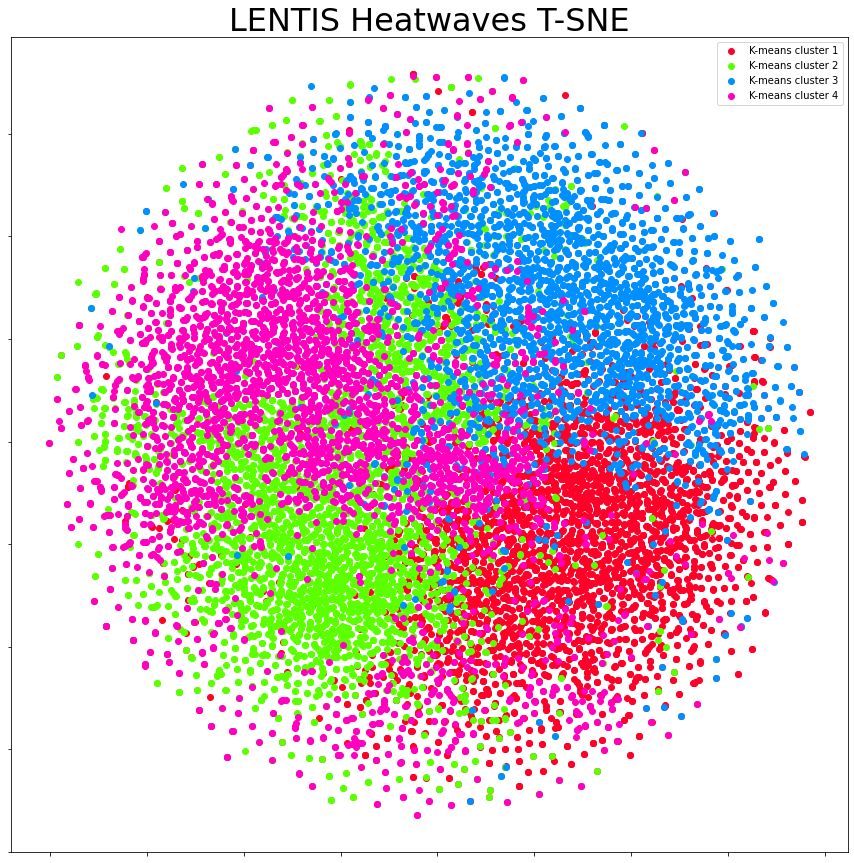

In [22]:
%matplotlib inline

clusters = np.unique(LENTIS_classes)
cmap = matplotlib.cm.get_cmap('gist_rainbow', clusters.shape[0])

fig = plt.figure(figsize=(15,15))
for clusternr in clusters:
    ix= np.where(LENTIS_classes == clusternr)
    clusternr = int(clusternr)
    plt.scatter(embedding_train[ix,0], embedding_train[ix, 1], 
                color=cmap(clusternr), 
                label=f"K-means cluster {1+clusternr}") 

plt.tick_params(labelleft=False,labelbottom=False)    

plt.title("LENTIS Heatwaves T-SNE", fontsize=32)
plt.legend()

# embedding into LENTIS space

https://opentsne.readthedocs.io/en/stable/api/index.html#openTSNE.TSNEEmbedding.transform 

So it only puts the points with respect to the existing space, it does not take into account the space between the points themselves

In [23]:
embedding_era5 = embedding_train.transform(heatwave_means_era5.to_numpy())

===> Finding 15 nearest neighbors in existing embedding using Annoy approximate search...
   --> Time elapsed: 0.07 seconds
===> Calculating affinity matrix...
   --> Time elapsed: 0.01 seconds
===> Running optimization with exaggeration=4.00, lr=0.10 for 0 iterations...
   --> Time elapsed: 0.00 seconds
===> Running optimization with exaggeration=1.50, lr=0.10 for 250 iterations...
Iteration   50, KL divergence 10236.0308, 50 iterations in 31.4529 sec
Iteration  100, KL divergence 9954.0783, 50 iterations in 31.4524 sec
Iteration  150, KL divergence 9843.6466, 50 iterations in 31.4990 sec
Iteration  200, KL divergence 9800.4541, 50 iterations in 31.5022 sec
Iteration  250, KL divergence 9770.1651, 50 iterations in 31.5063 sec
   --> Time elapsed: 157.41 seconds


In [24]:
embedding_era5.shape

(739, 2)

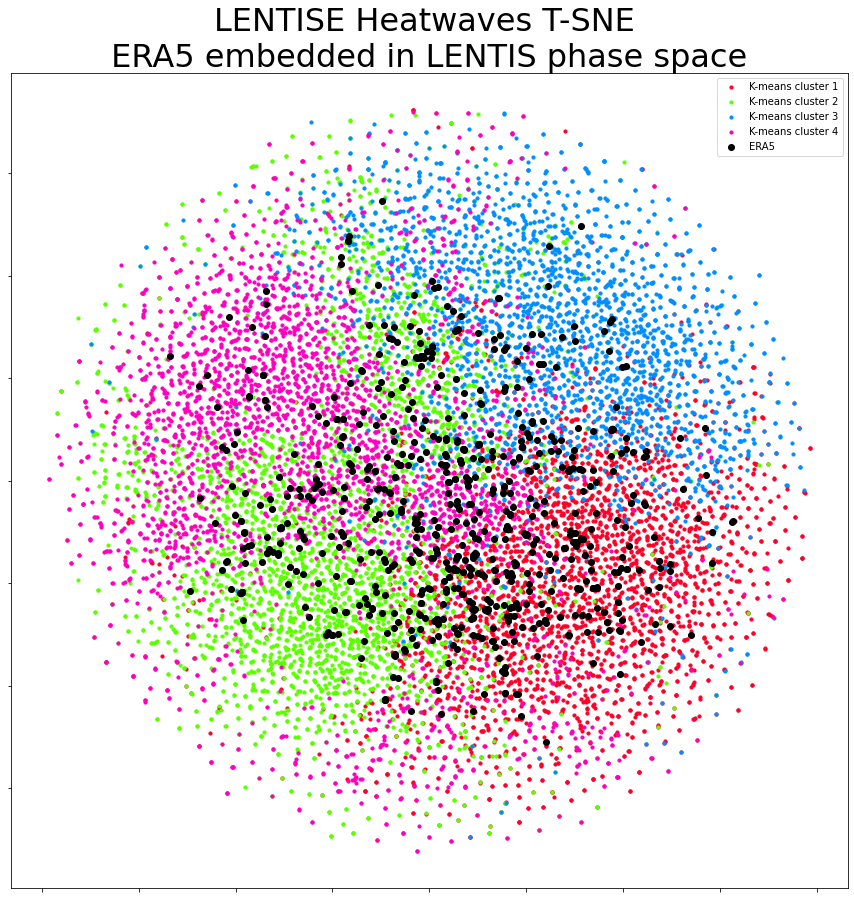

In [25]:
%matplotlib inline

clusters = np.unique(LENTIS_classes)
cmap = matplotlib.cm.get_cmap('gist_rainbow', clusters.shape[0])

fig = plt.figure(figsize=(15,15))
for clusternr in clusters:
    ix= np.where(LENTIS_classes == clusternr)
    clusternr = int(clusternr)
    plt.scatter(embedding_train[ix,0], embedding_train[ix, 1], 
                color=cmap(clusternr), 
                s=10,
                label=f"K-means cluster {1+clusternr}") 
    
plt.scatter(embedding_era5[:,0], embedding_era5[:,1],
           color="black",
           label="ERA5")

plt.tick_params(labelleft=False,labelbottom=False)    

plt.title("LENTISE Heatwaves T-SNE \n ERA5 embedded in LENTIS phase space ", fontsize=32)
plt.legend()

## ERA5 only

In [27]:
%time embedding_era5_only = tsne.fit(heatwave_means_era5.to_numpy())


--------------------------------------------------------------------------------
TSNE(early_exaggeration=12, n_jobs=100, random_state=42, verbose=True)
--------------------------------------------------------------------------------
===> Finding 90 nearest neighbors using exact search using euclidean distance...
   --> Time elapsed: 0.15 seconds
===> Calculating affinity matrix...
   --> Time elapsed: 0.01 seconds
===> Calculating PCA-based initialization...
   --> Time elapsed: 0.01 seconds
===> Running optimization with exaggeration=12.00, lr=61.58 for 250 iterations...
Iteration   50, KL divergence 1.0952, 50 iterations in 22.4790 sec
Iteration  100, KL divergence -1.5747, 50 iterations in 7.0670 sec
Iteration  150, KL divergence 2.9500, 50 iterations in 1.2296 sec
Iteration  200, KL divergence 2.9500, 50 iterations in 0.3297 sec
Iteration  250, KL divergence 2.9500, 50 iterations in 0.3354 sec
   --> Time elapsed: 31.44 seconds
===> Running optimization with exaggeration=1.00, lr=7

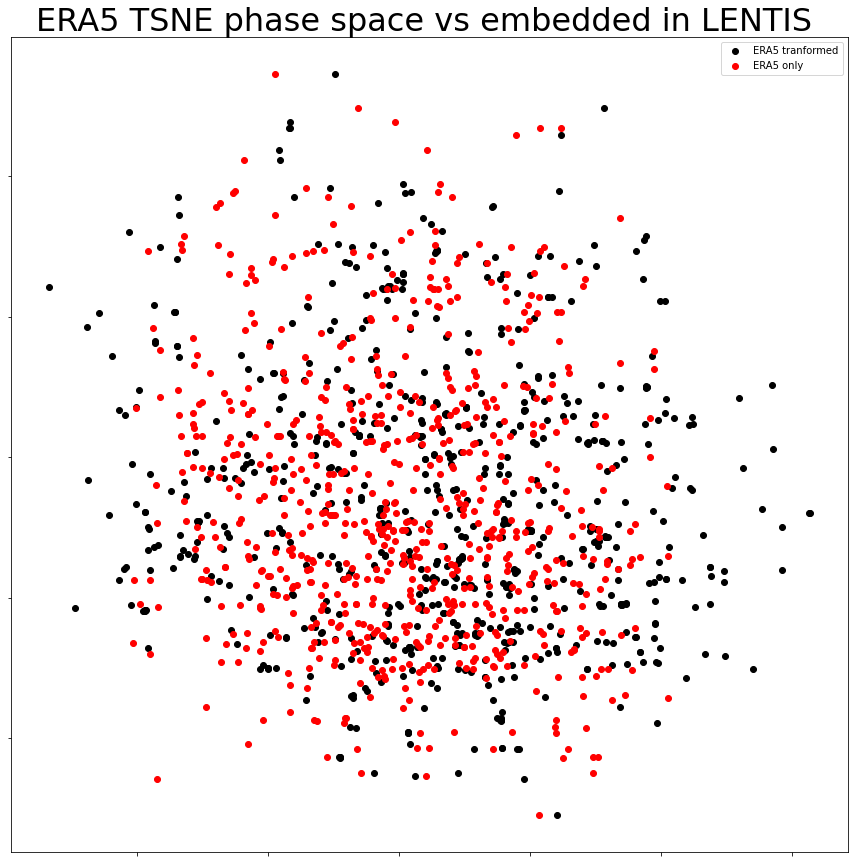

In [50]:
plt.scatter(embedding_era5[:,0], embedding_era5[:,1],
           color="black",
           label="ERA5 tranformed")

plt.scatter(embedding_era5_only[:,0], embedding_era5[:,1],
           color="red",
           label="ERA5 only")

plt.tick_params(labelleft=False,labelbottom=False)    

plt.title("ERA5 TSNE phase space vs embedded in LENTIS ", fontsize=32)

plt.rcParams["figure.figsize"] = (20,20)

plt.legend()
plt.show()

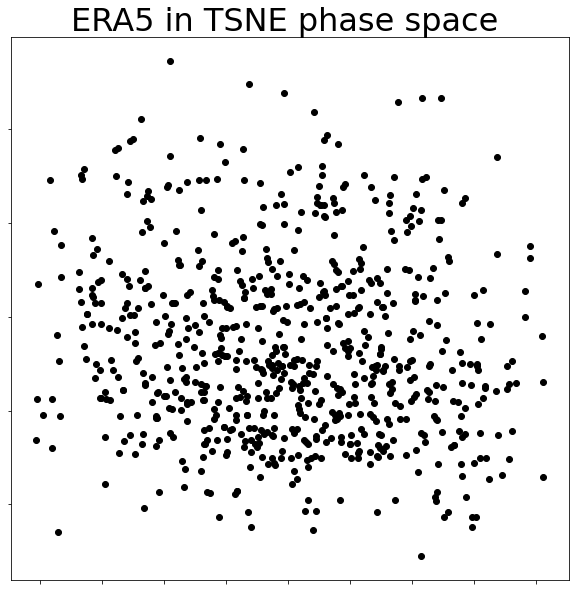

In [37]:
plt.scatter(embedding_era5_only[:,0], embedding_era5[:,1],
           color="black",
           label="ERA5")

plt.tick_params(labelleft=False,labelbottom=False)    

plt.title("ERA5 in TSNE phase space ", fontsize=32)
plt.rcParams["figure.figsize"] = (10,10)


plt.show()

# fit_tranform, needs a different package

In [38]:
from sklearn.manifold import TSNE

In [ ]:
TSNE(
    perplexity=30,
    metric="euclidean",
    n_jobs=100,
    random_state=42,
    verbose=True,
)

In [41]:
tsne = TSNE(learning_rate='auto',
                init='random', perplexity=3,
                 
                 n_jobs=100,
                 random_state=42, 
                 verbose=2,)

In [44]:
lentis_embedding = tsne.fit_transform(LENTIS_heatwave_means.to_numpy())

[t-SNE] Computing 10 nearest neighbors...
[t-SNE] Indexed 13878 samples in 0.005s...
[t-SNE] Computed neighbors for 13878 samples in 119.698s...
[t-SNE] Computed conditional probabilities for sample 1000 / 13878
[t-SNE] Computed conditional probabilities for sample 2000 / 13878
[t-SNE] Computed conditional probabilities for sample 3000 / 13878
[t-SNE] Computed conditional probabilities for sample 4000 / 13878
[t-SNE] Computed conditional probabilities for sample 5000 / 13878
[t-SNE] Computed conditional probabilities for sample 6000 / 13878
[t-SNE] Computed conditional probabilities for sample 7000 / 13878
[t-SNE] Computed conditional probabilities for sample 8000 / 13878
[t-SNE] Computed conditional probabilities for sample 9000 / 13878
[t-SNE] Computed conditional probabilities for sample 10000 / 13878
[t-SNE] Computed conditional probabilities for sample 11000 / 13878
[t-SNE] Computed conditional probabilities for sample 12000 / 13878
[t-SNE] Computed conditional probabilities for s

In [45]:
era5_embedding_refit = tsne.fit_transform(heatwave_means_era5.to_numpy())

[t-SNE] Computing 10 nearest neighbors...
[t-SNE] Indexed 739 samples in 0.001s...
[t-SNE] Computed neighbors for 739 samples in 0.030s...
[t-SNE] Computed conditional probabilities for sample 739 / 739
[t-SNE] Mean sigma: 3.213681
[t-SNE] Computed conditional probabilities in 0.003s
[t-SNE] Iteration 50: error = 93.5450287, gradient norm = 0.0722130 (50 iterations in 0.064s)
[t-SNE] Iteration 100: error = 93.2974167, gradient norm = 0.0708663 (50 iterations in 0.058s)
[t-SNE] Iteration 150: error = 91.9727325, gradient norm = 0.0924030 (50 iterations in 0.055s)
[t-SNE] Iteration 200: error = 91.8147507, gradient norm = 0.1583209 (50 iterations in 0.054s)
[t-SNE] Iteration 250: error = 92.0981827, gradient norm = 0.0781492 (50 iterations in 0.055s)
[t-SNE] KL divergence after 250 iterations with early exaggeration: 92.098183
[t-SNE] Iteration 300: error = 2.1085067, gradient norm = 0.0289831 (50 iterations in 0.048s)
[t-SNE] Iteration 350: error = 1.7291644, gradient norm = 0.0159871 (

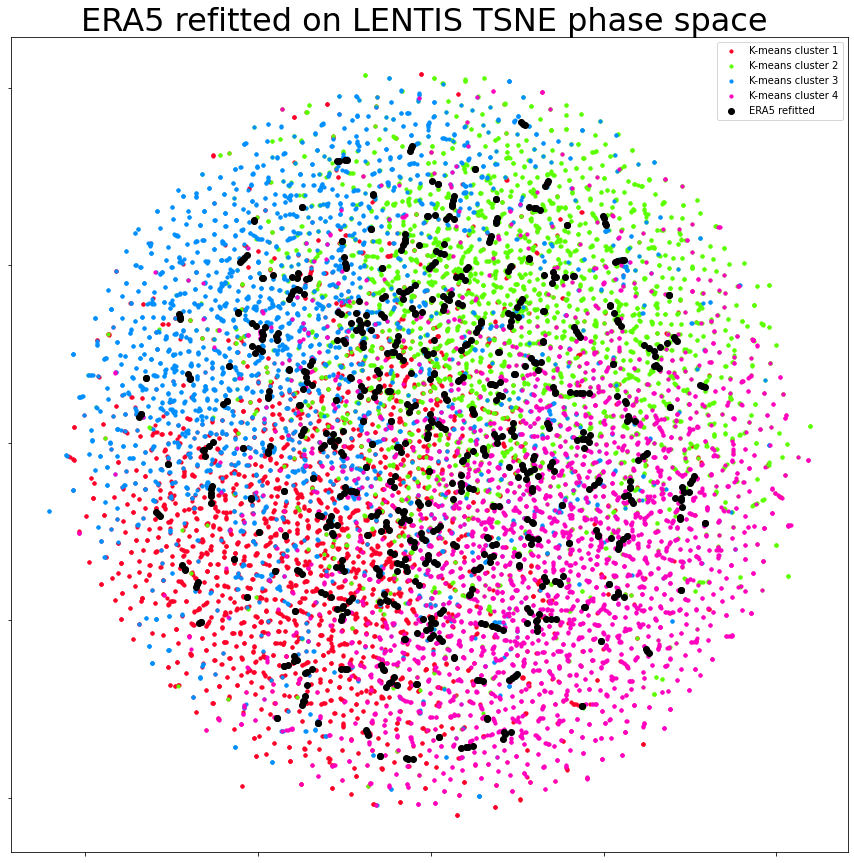

In [57]:
# plt.scatter(lentis_embedding[:,0], lentis_embedding[:,1],
#            color="blue",
#             s=10,
#            label="LENTIS")

clusters = np.unique(LENTIS_classes)
cmap = matplotlib.cm.get_cmap('gist_rainbow', clusters.shape[0])

fig = plt.figure(figsize=(15,15))
for clusternr in clusters:
    ix= np.where(LENTIS_classes == clusternr)
    clusternr = int(clusternr)
    plt.scatter(lentis_embedding[ix,0], lentis_embedding[ix, 1], 
                color=cmap(clusternr), 
                s=10,
                label=f"K-means cluster {1+clusternr}") 


plt.scatter(era5_embedding_refit[:,0], era5_embedding_refit[:,1],
           color="black",
           label="ERA5 refitted")

plt.tick_params(labelleft=False,labelbottom=False)    

plt.title("ERA5 refitted on LENTIS TSNE phase space ", fontsize=32)

plt.rcParams["figure.figsize"] = (12,12)

plt.legend()
plt.show()